# 03 - BO vs Random vs Grid vs RSM

Benchmark each strategy under equal evaluation budget (40 experiments).

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression

from botorch.fit import fit_gpytorch_mll
from botorch.models import SingleTaskGP
from botorch.models.transforms import Normalize, Standardize
from botorch.acquisition.analytic import LogExpectedImprovement
from botorch.optim import optimize_acqf
from gpytorch.mlls import ExactMarginalLogLikelihood

plt.style.use('seaborn-v0_8-whitegrid')
torch.set_default_dtype(torch.double)

In [2]:
import numpy as np
import pandas as pd

API_PCT = 30.0
TOTAL_EXCIPIENT_PCT = 100.0 - API_PCT

BOUNDS = {
    "hpmc": (0.0, 20.0),
    "mcc": (20.0, 60.0),
    "ccs": (1.0, 8.0),
    "mgst": (0.25, 2.0),
    "pvp": (0.0, 10.0),
}


def _physics_q45(hpmc, mcc, ccs, mgst, pvp):
    """
    Physics-informed synthetic dissolution model (% released at 45 min).

    Scientific assumptions encoded:
    - HPMC retards dissolution with nonlinear gel-layer penalty.
    - CCS improves dissolution with a saturable response.
    - MgSt reduces dissolution due to hydrophobic film formation.
    - MCC and PVP provide mild positive wetting/compactibility effects.
    - HPMC × CCS interaction reduces CCS effectiveness at high HPMC.
    """
    ccs_gain = 24.0 * (1.0 - np.exp(-ccs / 2.2))
    q45 = (
        48.0
        + 0.45 * mcc
        + 0.90 * pvp
        + ccs_gain
        - 1.05 * hpmc
        - 0.035 * (hpmc ** 2)
        - 7.2 * mgst
        - 0.16 * hpmc * ccs
    )
    return np.clip(q45, 0.0, 100.0)


def simulate_dissolution(df, noise_std=2.0, seed=0):
    """Simulate Q45 for one or many formulations."""
    rng = np.random.default_rng(seed)
    expected = _physics_q45(
        df["hpmc"].to_numpy(),
        df["mcc"].to_numpy(),
        df["ccs"].to_numpy(),
        df["mgst"].to_numpy(),
        df["pvp"].to_numpy(),
    )
    observed = expected + rng.normal(0.0, noise_std, size=len(df))
    return np.clip(observed, 0.0, 100.0)


def is_feasible(df):
    """Check formulation bounds and mass-balance constraints."""
    checks = []
    for name, (lo, hi) in BOUNDS.items():
        checks.append(df[name].between(lo, hi))
    sum_ok = np.isclose(df[["hpmc", "mcc", "ccs", "mgst", "pvp"]].sum(axis=1), TOTAL_EXCIPIENT_PCT, atol=1e-6)
    return np.logical_and.reduce(checks + [sum_ok])


def sample_feasible(n, seed=0):
    """Rejection sample feasible formulations under x5 = 70 - (x1+x2+x3+x4)."""
    rng = np.random.default_rng(seed)
    rows = []
    while len(rows) < n:
        hpmc = rng.uniform(*BOUNDS["hpmc"])
        mcc = rng.uniform(*BOUNDS["mcc"])
        ccs = rng.uniform(*BOUNDS["ccs"])
        mgst = rng.uniform(*BOUNDS["mgst"])
        pvp = TOTAL_EXCIPIENT_PCT - (hpmc + mcc + ccs + mgst)
        if BOUNDS["pvp"][0] <= pvp <= BOUNDS["pvp"][1]:
            rows.append((hpmc, mcc, ccs, mgst, pvp))
    return pd.DataFrame(rows, columns=["hpmc", "mcc", "ccs", "mgst", "pvp"])

In [3]:
TORCH_BOUNDS = torch.tensor([
    [BOUNDS["hpmc"][0], BOUNDS["mcc"][0], BOUNDS["ccs"][0], BOUNDS["mgst"][0]],
    [BOUNDS["hpmc"][1], BOUNDS["mcc"][1], BOUNDS["ccs"][1], BOUNDS["mgst"][1]],
], dtype=torch.double)


def sample_sobol_feasible(n, seed=0):
    sobol = torch.quasirandom.SobolEngine(dimension=4, scramble=True, seed=seed)
    out = []
    while len(out) < n:
        X = sobol.draw(4 * n)
        X = TORCH_BOUNDS[0] + (TORCH_BOUNDS[1] - TORCH_BOUNDS[0]) * X
        pvp = TOTAL_EXCIPIENT_PCT - X.sum(dim=-1)
        X = X[(pvp >= BOUNDS["pvp"][0]) & (pvp <= BOUNDS["pvp"][1])]
        out.extend([x for x in X])
    return torch.stack(out[:n])


def augment_with_pvp(X4):
    pvp = TOTAL_EXCIPIENT_PCT - X4.sum(dim=-1, keepdim=True)
    return torch.cat([X4, pvp], dim=-1)


def simulate_torch(X4, seed=0):
    X = augment_with_pvp(X4).detach().cpu().numpy()
    df = pd.DataFrame(X, columns=["hpmc", "mcc", "ccs", "mgst", "pvp"])
    y = simulate_dissolution(df, seed=seed)
    return torch.tensor(y, dtype=torch.double).unsqueeze(-1)

In [4]:
def run_random_search(n_eval=40, seed=0):
    df = sample_feasible(n_eval, seed=seed)
    y = simulate_dissolution(df, seed=seed)
    return np.maximum.accumulate(y)


def run_grid_search(n_eval=40, seed=0):
    # Dense discrete grid filtered by feasibility, then topologically ordered sweep.
    hpmc = np.linspace(*BOUNDS["hpmc"], 9)
    mcc = np.linspace(*BOUNDS["mcc"], 9)
    ccs = np.linspace(*BOUNDS["ccs"], 8)
    mgst = np.linspace(*BOUNDS["mgst"], 6)
    rows = []
    for x1 in hpmc:
        for x2 in mcc:
            for x3 in ccs:
                for x4 in mgst:
                    x5 = TOTAL_EXCIPIENT_PCT - (x1 + x2 + x3 + x4)
                    if BOUNDS["pvp"][0] <= x5 <= BOUNDS["pvp"][1]:
                        rows.append((x1, x2, x3, x4, x5))
    grid = pd.DataFrame(rows, columns=["hpmc", "mcc", "ccs", "mgst", "pvp"])
    # Deterministic pseudo-random ordering for fair budget-limited grid sampling.
    grid = grid.sample(frac=1.0, random_state=seed).reset_index(drop=True).head(n_eval)
    y = simulate_dissolution(grid, seed=seed + 77)
    return np.maximum.accumulate(y)


def run_rsm_guided(n_eval=40, n_init=12, seed=0):
    train = sample_feasible(n_init, seed=seed)
    train["q45"] = simulate_dissolution(train, seed=seed)

    pool = sample_feasible(2500, seed=seed + 100)
    feats = ["hpmc", "mcc", "ccs", "mgst", "pvp"]

    init_trace = np.maximum.accumulate(train["q45"].to_numpy())
    best_trace = list(init_trace)

    while len(train) < n_eval:
        model = Pipeline([
            ("poly", PolynomialFeatures(degree=2, include_bias=False)),
            ("scaler", StandardScaler()),
            ("lr", LinearRegression()),
        ])
        model.fit(train[feats], train["q45"])

        pred = model.predict(pool[feats])
        idx = int(np.argmax(pred))
        x_next = pool.iloc[[idx]].copy()
        y_next = simulate_dissolution(x_next, seed=seed + len(train) + 200)
        x_next["q45"] = y_next

        train = pd.concat([train, x_next], ignore_index=True)
        pool = pool.drop(index=idx).reset_index(drop=True)
        best_trace.append(max(best_trace[-1], float(y_next[0])))

    return np.array(best_trace[:n_eval])


def run_bo(n_eval=40, n_init=10, seed=0):
    X = sample_sobol_feasible(n_init, seed=seed)
    Y = simulate_torch(X, seed=seed)
    trace = list(np.maximum.accumulate(Y.detach().cpu().numpy().ravel()))

    ineq = [
        (torch.tensor([0, 1, 2, 3]), torch.tensor([1.0, 1.0, 1.0, 1.0], dtype=torch.double), 60.0),
        (torch.tensor([0, 1, 2, 3]), torch.tensor([-1.0, -1.0, -1.0, -1.0], dtype=torch.double), -70.0),
    ]

    for t in range(n_init, n_eval):
        model = SingleTaskGP(
            X,
            Y,
            input_transform=Normalize(d=4),
            outcome_transform=Standardize(m=1),
        )
        mll = ExactMarginalLogLikelihood(model.likelihood, model)
        fit_gpytorch_mll(mll)

        acqf = LogExpectedImprovement(model, best_f=Y.max())
        x_next, _ = optimize_acqf(
            acq_function=acqf,
            bounds=TORCH_BOUNDS,
            q=1,
            num_restarts=15,
            raw_samples=192,
            inequality_constraints=ineq,
        )
        y_next = simulate_torch(x_next, seed=seed + 1000 + t)

        X = torch.cat([X, x_next], dim=0)
        Y = torch.cat([Y, y_next], dim=0)
        trace.append(max(trace[-1], float(y_next.item())))

    return np.array(trace)

In [5]:
n_trials = 10
budget = 40

results = {"bo": [], "random": [], "grid": [], "rsm": []}
for trial in range(n_trials):
    seed = 100 + trial
    results["bo"].append(run_bo(n_eval=budget, seed=seed))
    results["random"].append(run_random_search(n_eval=budget, seed=seed))
    results["grid"].append(run_grid_search(n_eval=budget, seed=seed))
    results["rsm"].append(run_rsm_guided(n_eval=budget, seed=seed))

summary = {k: np.vstack(v) for k, v in results.items()}
{k: v.shape for k, v in summary.items()}

{'bo': (10, 40), 'random': (10, 40), 'grid': (10, 40), 'rsm': (10, 40)}

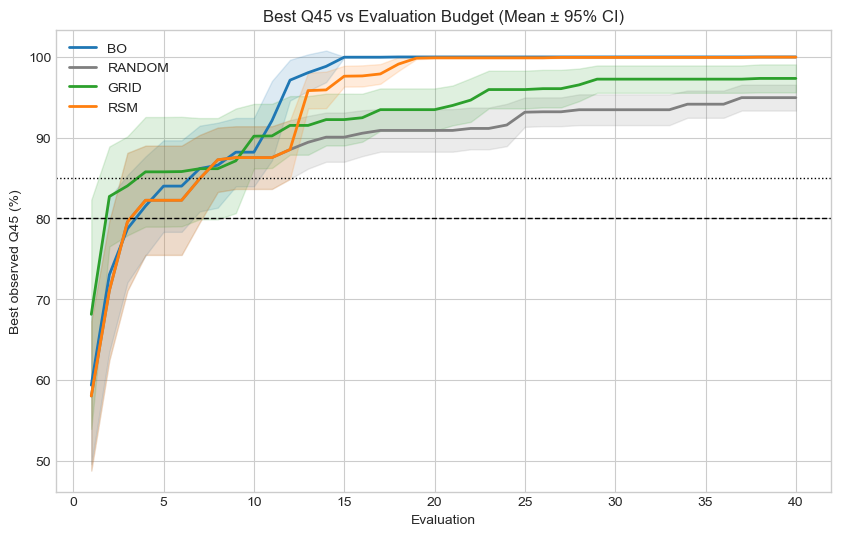

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))
xs = np.arange(1, budget + 1)

for name, color in [("bo", "tab:blue"), ("random", "tab:gray"), ("grid", "tab:green"), ("rsm", "tab:orange")]:
    arr = summary[name]
    mu = arr.mean(axis=0)
    se = arr.std(axis=0) / np.sqrt(arr.shape[0])
    ax.plot(xs, mu, label=name.upper(), color=color, lw=2)
    ax.fill_between(xs, mu - 1.96 * se, mu + 1.96 * se, color=color, alpha=0.15)

ax.axhline(80, ls='--', color='black', lw=1)
ax.axhline(85, ls=':', color='black', lw=1)
ax.set_title("Best Q45 vs Evaluation Budget (Mean ± 95% CI)")
ax.set_xlabel("Evaluation")
ax.set_ylabel("Best observed Q45 (%)")
ax.legend()
plt.show()

In [7]:
def first_hit(trace, threshold):
    idx = np.where(trace >= threshold)[0]
    return int(idx[0] + 1) if len(idx) else np.nan

rows = []
for method, arr in summary.items():
    hit80 = [first_hit(t, 80) for t in arr]
    hit85 = [first_hit(t, 85) for t in arr]
    rows.append({
        "method": method.upper(),
        "mean_best_q45": np.nanmean(arr[:, -1]),
        "mean_eval_to_80": np.nanmean(hit80),
        "mean_eval_to_85": np.nanmean(hit85),
    })

pd.DataFrame(rows).round(2).sort_values("mean_best_q45", ascending=False)

,method,mean_best_q45,mean_eval_to_80,mean_eval_to_85
0,BO,100.00,4.9,6.8
3,RSM,99.98,4.2,9.3
2,GRID,97.34,2.5,7.3
1,RANDOM,94.96,4.2,11.3


## Benchmark interpretation

- BO should reach Q45 > 80 with fewer evaluations than random/grid under fixed budget.
- RSM may perform competitively early but usually plateaus on nonlinear regions.
- Remaining limitations: synthetic simulator, moderate-dimensional (5-variable) design space.